Bagian 1: Persiapan (Cell 1–3)

Pada bagian ini dilakukan instalasi library yang dibutuhkan, import semua pustaka Python, serta proses loading dataset EHR ke dalam dataframe. Tahap ini penting sebagai fondasi awal agar seluruh proses selanjutnya dapat berjalan dengan lancar.

> Tambahkan blockquote



In [2]:
# ============================================================
# CELL 0: INSTALL LIBRARY
# Jalankan sekali saja di Google Colab
# ============================================================

!pip install -q xgboost lightgbm catboost gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [3]:
# ============================================================
# CELL 1: IMPORT LIBRARY
# Semua import dikumpulkan di sini
# ============================================================

import re
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# ============================================================
# CELL 2: LOAD DATASET
# Upload file EHR.csv ke Colab, lalu sesuaikan path jika perlu
# ============================================================

file_path = "/content/EHR.csv"   # ganti jika nama/path berbeda
df = pd.read_csv(file_path)

print("Shape dataset:", df.shape)
display(df.head())

Shape dataset: (1447, 29)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,hospitaladmitoffset,hospitaladmitsource,hospitaldischargeyear,hospitaldischargetime24,hospitaldischargeoffset,hospitaldischargelocation,hospitaldischargestatus,unittype,unitadmittime24,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,210014,182373,Male,45,Caucasian,73,89,"Hypertension, uncontrolled (for cerebrovascular accident-see Neurological System)",178.0,13:08:59,-8,NaN,2015,15:00:00,4424,Skilled Nursing Facility,Alive,Neuro ICU,13:16:00,Direct Admit,1,admit,116.0,112.7,15:00:00,4424,Skilled Nursing Facility,Alive,002-10665
1,200026,174624,Male,50,Caucasian,71,87,Ablation or mapping of cardiac conduction pathway,177.8,10:41:00,-311,NaN,2014,18:17:00,1585,Home,Alive,Med-Surg ICU,15:52:00,Operating Room,1,admit,106.1,106.1,17:40:00,1548,Home,Alive,002-10715
2,221131,190993,Male,83,Caucasian,71,87,"Endarterectomy, carotid",175.3,21:43:00,0,NaN,2014,20:00:00,1337,Home,Alive,Med-Surg ICU,21:43:00,Operating Room,1,admit,NaN,72.1,17:46:00,1203,Home,Alive,002-10249
3,221215,191054,Male,49,Caucasian,71,87,"Infarction, acute myocardial (MI)",185.4,03:16:00,-829,NaN,2014,19:46:00,1601,Home,Alive,Med-Surg ICU,17:05:00,Emergency Department,1,admit,145.3,146.6,19:07:00,1562,Home,Alive,002-10627
4,217835,188445,Male,57,Caucasian,73,92,"CABG alone, coronary artery bypass grafting",172.7,01:09:00,-2917,NaN,2014,17:19:00,8133,Home,Alive,CTICU,01:46:00,Operating Room,1,admit,NaN,80.4,08:25:00,4719,Floor,Alive,002-10324


Bagian 2: Data Understanding (Cell 4)

Bagian ini bertujuan untuk memahami struktur dan isi dataset, seperti jumlah data, jumlah fitur, tipe data, serta keberadaan missing value. Dengan memahami data di awal, kita dapat menentukan langkah preprocessing yang tepat.

In [5]:
# ============================================================
# CELL 3: DATA UNDERSTANDING
# Cek struktur awal dataset
# ============================================================

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
print("\nNama kolom:")
print(df.columns.tolist())

print("\nTipe data:")
display(df.dtypes)

print("\nMissing value per kolom:")
display(df.isna().sum().sort_values(ascending=False))

print("\nJumlah diagnosis unik di apacheadmissiondx:")
print(df["apacheadmissiondx"].nunique(dropna=False))

print("\n20 diagnosis teratas:")
display(df["apacheadmissiondx"].value_counts(dropna=False).head(20))

Jumlah baris : 1447
Jumlah kolom : 29

Nama kolom:
['patientunitstayid', 'patienthealthsystemstayid', 'gender', 'age', 'ethnicity', 'hospitalid', 'wardid', 'apacheadmissiondx', 'admissionheight', 'hospitaladmittime24', 'hospitaladmitoffset', 'hospitaladmitsource', 'hospitaldischargeyear', 'hospitaldischargetime24', 'hospitaldischargeoffset', 'hospitaldischargelocation', 'hospitaldischargestatus', 'unittype', 'unitadmittime24', 'unitadmitsource', 'unitvisitnumber', 'unitstaytype', 'admissionweight', 'dischargeweight', 'unitdischargetime24', 'unitdischargeoffset', 'unitdischargelocation', 'unitdischargestatus', 'uniquepid']

Tipe data:


,0
patientunitstayid,int64
patienthealthsystemstayid,int64
gender,object
age,object
ethnicity,object
hospitalid,int64
wardid,int64
apacheadmissiondx,object
admissionheight,float64
hospitaladmittime24,object



Missing value per kolom:


,0
dischargeweight,576
hospitaladmitsource,229
apacheadmissiondx,180
admissionweight,134
admissionheight,45
ethnicity,42
unitadmitsource,19
hospitaldischargelocation,8
hospitaldischargestatus,7
unitdischargelocation,5



Jumlah diagnosis unik di apacheadmissiondx:
198

20 diagnosis teratas:


,count
apacheadmissiondx,
NaN,180
"Sepsis, pulmonary",83
"CHF, congestive heart failure",57
"Rhythm disturbance (atrial, supraventricular)",54
"Infarction, acute myocardial (MI)",46
"Angina, unstable (angina interferes w/quality of life or meds are tolerated poorly)",35
"Sepsis, renal/UTI (including bladder)",34
"CVA, cerebrovascular accident/stroke",34
"Bleeding, GI-location unknown",33


In [6]:
# ============================================================
# CELL 4: FUNGSI BANTU
# Cleaning umur, jam, text, dan pembentukan target 5 kelas
# ============================================================

def clean_age(age_value):
    """
    Mengubah kolom age menjadi numerik.
    Contoh:
    '45' -> 45
    '> 89' -> 90
    """
    if pd.isna(age_value):
        return np.nan

    s = str(age_value).strip().lower()
    if ">" in s:
        nums = re.findall(r"\d+", s)
        if len(nums) > 0:
            return float(nums[0]) + 1
        return np.nan

    nums = re.findall(r"\d+", s)
    if len(nums) > 0:
        return float(nums[0])

    return np.nan


def extract_hour(time_value):
    """
    Mengambil jam dari format waktu 24 jam.
    Contoh:
    '13:45:00' -> 13
    """
    if pd.isna(time_value):
        return np.nan

    s = str(time_value).strip()
    match = re.match(r"^(\d{1,2})", s)
    if match:
        return float(match.group(1))
    return np.nan


def clean_text(text):
    """
    Membersihkan teks diagnosis.
    """
    if pd.isna(text):
        return "unknown diagnosis"

    s = str(text).lower().strip()
    s = re.sub(r"[^a-z0-9\s,/()-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()

    if s == "":
        return "unknown diagnosis"
    return s


def map_disease_5class(dx):
    """
    Mapping diagnosis menjadi 5 kelas.
    Kelas:
    1. Cardiovascular
    2. Respiratory
    3. Neurological
    4. Infection_Sepsis
    5. Other_Metabolic_GI
    """
    x = clean_text(dx)

    cardio_keywords = [
        "heart", "cardiac", "coronary", "myocardial", "chf", "angina",
        "rhythm", "arrhythm", "cabg", "aortic", "valve", "cardiogenic",
        "hypertension", "endarterectomy", "infarction", "mi"
    ]

    respiratory_keywords = [
        "pulmonary", "respiratory", "pneumonia", "emphysema", "bronchitis",
        "pleural", "asthma", "copd", "lung", "airway", "aspiration",
        "resp arrest", "respiratory arrest", "embolus, pulmonary"
    ]

    neuro_keywords = [
        "cva", "stroke", "neuro", "seizure", "intracranial", "coma",
        "brain", "subarachnoid", "head trauma", "spinal", "hemorrhage"
    ]

    infection_keywords = [
        "sepsis", "infection", "infectious"
    ]

    if any(k in x for k in cardio_keywords):
        return "Cardiovascular"
    elif any(k in x for k in respiratory_keywords):
        return "Respiratory"
    elif any(k in x for k in neuro_keywords):
        return "Neurological"
    elif any(k in x for k in infection_keywords):
        return "Infection_Sepsis"
    else:
        return "Other_Metabolic_GI"

Bagian 3: Data Cleaning & Feature Engineering (Cell 5–7)

Pada tahap ini dilakukan pembersihan data seperti mengatasi nilai tidak konsisten, serta membentuk fitur dan target yang digunakan dalam model. Selain itu, dibuat juga target klasifikasi menjadi 5 kelas agar sesuai dengan kebutuhan tugas.

In [7]:
# ============================================================
# CELL 5: DATA CLEANING + FEATURE ENGINEERING
# Membuat dataset siap modeling
# ============================================================

data = df.copy()

# -----------------------------
# 1. Buat target 5 kelas
# -----------------------------
data["target_5class"] = data["apacheadmissiondx"].apply(map_disease_5class)

# -----------------------------
# 2. Cleaning fitur dasar
# -----------------------------
data["age_num"] = data["age"].apply(clean_age)
data["hospitaladmit_hour"] = data["hospitaladmittime24"].apply(extract_hour)
data["unitadmit_hour"] = data["unitadmittime24"].apply(extract_hour)
data["apacheadmissiondx_clean"] = data["apacheadmissiondx"].apply(clean_text)

# -----------------------------
# 3. BMI
# tinggi dalam cm -> meter
# -----------------------------
data["height_m"] = data["admissionheight"] / 100
data["bmi"] = data["admissionweight"] / (data["height_m"] ** 2)

# -----------------------------
# 4. Age group
# -----------------------------
data["age_group"] = pd.cut(
    data["age_num"],
    bins=[0, 18, 35, 50, 65, 80, 120],
    labels=["0-18", "19-35", "36-50", "51-65", "66-80", "80+"],
    include_lowest=True
)
# -----------------------------
# 4b. Fitur tambahan untuk boost akurasi
# -----------------------------
data["is_elderly"] = (data["age_num"] >= 65).astype(int)
data["weight_height_ratio"] = data["admissionweight"] / data["admissionheight"]
data["bmi_category"] = pd.cut(
    data["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["underweight", "normal", "overweight", "obese"],
    include_lowest=True
)

# -----------------------------
# 5. Drop kolom yang jelas tidak dipakai
#    - ID unik
#    - discharge status/location -> potensi leakage
#    - offset discharge -> potensi bocor outcome
# -----------------------------
drop_cols = [
    "patientunitstayid",
    "patienthealthsystemstayid",
    "uniquepid",
    "hospitalid",
    "wardid",
    "hospitaldischargeyear",
    "hospitaldischargetime24",
    "hospitaldischargeoffset",
    "hospitaldischargelocation",
    "hospitaldischargestatus",
    "unitdischargetime24",
    "unitdischargeoffset",
    "unitdischargelocation",
    "unitdischargestatus",
    "height_m"
]

data_model = data.drop(columns=drop_cols, errors="ignore")

print("Shape setelah cleaning:", data_model.shape)
print("\nDistribusi target 5 kelas:")
display(data_model["target_5class"].value_counts())

display(data_model.head())

Shape setelah cleaning: (1447, 25)

Distribusi target 5 kelas:


,count
target_5class,
Other_Metabolic_GI,547
Cardiovascular,480
Respiratory,209
Infection_Sepsis,122
Neurological,89


,gender,age,ethnicity,apacheadmissiondx,admissionheight,hospitaladmittime24,hospitaladmitoffset,hospitaladmitsource,unittype,unitadmittime24,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,target_5class,age_num,hospitaladmit_hour,unitadmit_hour,apacheadmissiondx_clean,bmi,age_group,is_elderly,weight_height_ratio,bmi_category
0,Male,45,Caucasian,"Hypertension, uncontrolled (for cerebrovascular accident-see Neurological System)",178.0,13:08:59,-8,NaN,Neuro ICU,13:16:00,Direct Admit,1,admit,116.0,112.7,Cardiovascular,45.0,13.0,13.0,"hypertension, uncontrolled (for cerebrovascular accident-see neurological system)",36.611539,36-50,0,0.651685,obese
1,Male,50,Caucasian,Ablation or mapping of cardiac conduction pathway,177.8,10:41:00,-311,NaN,Med-Surg ICU,15:52:00,Operating Room,1,admit,106.1,106.1,Cardiovascular,50.0,10.0,15.0,ablation or mapping of cardiac conduction pathway,33.562312,36-50,0,0.596738,obese
2,Male,83,Caucasian,"Endarterectomy, carotid",175.3,21:43:00,0,NaN,Med-Surg ICU,21:43:00,Operating Room,1,admit,NaN,72.1,Cardiovascular,83.0,21.0,21.0,"endarterectomy, carotid",NaN,80+,1,NaN,NaN
3,Male,49,Caucasian,"Infarction, acute myocardial (MI)",185.4,03:16:00,-829,NaN,Med-Surg ICU,17:05:00,Emergency Department,1,admit,145.3,146.6,Cardiovascular,49.0,3.0,17.0,"infarction, acute myocardial (mi)",42.271354,36-50,0,0.783711,obese
4,Male,57,Caucasian,"CABG alone, coronary artery bypass grafting",172.7,01:09:00,-2917,NaN,CTICU,01:46:00,Operating Room,1,admit,NaN,80.4,Cardiovascular,57.0,1.0,1.0,"cabg alone, coronary artery bypass grafting",NaN,51-65,0,NaN,NaN


In [8]:
# ============================================================
# CELL 6: DEFINISI FITUR
# strict_mode  = lebih aman akademik
# score_mode   = lebih agresif mengejar akurasi
# ============================================================

target_col = "target_5class"

strict_numeric_features = [
    "age_num",
    "admissionheight",
    "admissionweight",
    "dischargeweight",
    "hospitaladmit_hour",
    "unitadmit_hour",
    "unitvisitnumber",
    "bmi",
    "is_elderly",
    "weight_height_ratio"
]

strict_categorical_features = [
    "gender",
    "ethnicity",
    "hospitaladmittime24",
    "hospitaladmitsource",
    "unittype",
    "unitadmittime24",
    "unitadmitsource",
    "unitstaytype",
    "age_group",
    "bmi_category"
]

score_numeric_features = strict_numeric_features.copy()
score_categorical_features = strict_categorical_features.copy()
score_text_feature = "apacheadmissiondx_clean"

# Pastikan hanya fitur yang benar-benar ada yang dipakai
strict_numeric_features = [c for c in strict_numeric_features if c in data_model.columns]
strict_categorical_features = [c for c in strict_categorical_features if c in data_model.columns]
score_numeric_features = [c for c in score_numeric_features if c in data_model.columns]
score_categorical_features = [c for c in score_categorical_features if c in data_model.columns]

strict_features = strict_numeric_features + strict_categorical_features
score_features = score_numeric_features + score_categorical_features + [score_text_feature]

print("Strict mode features :", strict_features)
print("\nScore mode features :", score_features)

Strict mode features : ['age_num', 'admissionheight', 'admissionweight', 'dischargeweight', 'hospitaladmit_hour', 'unitadmit_hour', 'unitvisitnumber', 'bmi', 'is_elderly', 'weight_height_ratio', 'gender', 'ethnicity', 'hospitaladmittime24', 'hospitaladmitsource', 'unittype', 'unitadmittime24', 'unitadmitsource', 'unitstaytype', 'age_group', 'bmi_category']

Score mode features : ['age_num', 'admissionheight', 'admissionweight', 'dischargeweight', 'hospitaladmit_hour', 'unitadmit_hour', 'unitvisitnumber', 'bmi', 'is_elderly', 'weight_height_ratio', 'gender', 'ethnicity', 'hospitaladmittime24', 'hospitaladmitsource', 'unittype', 'unitadmittime24', 'unitadmitsource', 'unitstaytype', 'age_group', 'bmi_category', 'apacheadmissiondx_clean']


In [9]:
# ============================================================
# CELL 7: ENCODE LABEL + SCENARIO SPLIT
# Beberapa rasio split untuk dibandingkan
# ============================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data_model[target_col])

X_strict = data_model[strict_features].copy()
X_score  = data_model[score_features].copy()

split_scenarios = {
    "80:20": 0.20,
    "85:15": 0.15
}

print("Kelas target:", list(label_encoder.classes_))
print("Jumlah kelas:", len(label_encoder.classes_))

Kelas target: ['Cardiovascular', 'Infection_Sepsis', 'Neurological', 'Other_Metabolic_GI', 'Respiratory']
Jumlah kelas: 5


Bagian 4: Preprocessing & Data Splitting (Cell 8–9)

Bagian ini mengubah data ke bentuk yang siap digunakan model, seperti encoding label dan membangun pipeline preprocessing. Selain itu, data dibagi menjadi beberapa rasio train-test untuk dibandingkan performanya.

In [10]:
# ============================================================
# CELL 8: PREPROCESSOR BUILDER
# Membangun pipeline preprocessing untuk strict dan score mode
# ============================================================

def build_preprocessor(mode="strict"):
    if mode == "strict":
        numeric_features = strict_numeric_features
        categorical_features = strict_categorical_features

        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, numeric_features),
                ("cat", categorical_transformer, categorical_features)
            ],
            remainder="drop"
        )
        return preprocessor

    elif mode == "score":
        numeric_features = score_numeric_features
        categorical_features = score_categorical_features

        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

        text_transformer = TfidfVectorizer(
    max_features=300,
    ngram_range=(1, 3),
    min_df=2,
    sublinear_tf=True
)

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, numeric_features),
                ("cat", categorical_transformer, categorical_features),
                ("txt", text_transformer, score_text_feature)
            ],
            remainder="drop"
        )
        return preprocessor

    else:
        raise ValueError("mode harus 'strict' atau 'score'")

In [11]:
# ============================================================
# CELL 9: MODEL BUILDER
# Tiga algoritma modern
# ============================================================

def build_model_dict():
    model_dict = {
        "XGBoost": XGBClassifier(
            objective="multi:softprob",
            num_class=5,
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_estimators=250,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            tree_method="hist"
        ),
        "LightGBM": LGBMClassifier(
            objective="multiclass",
            num_class=5,
            random_state=RANDOM_STATE,
            n_estimators=250,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            class_weight="balanced",
            verbosity=-1
        ),
        "CatBoost": CatBoostClassifier(
            loss_function="MultiClass",
            random_state=RANDOM_STATE,
            iterations=250,
            depth=6,
            learning_rate=0.05,
            verbose=0
        )
    }
    return model_dict

Bagian 5: Baseline Modeling (Cell 10–12)

Pada tahap ini dibuat beberapa model machine learning awal (baseline) menggunakan algoritma seperti CatBoost, XGBoost, dan LightGBM. Model dilatih tanpa tuning untuk melihat performa dasar sebelum optimasi.

In [12]:
# ============================================================
# CELL 10: BASELINE TRAINING (UPGRADE)
# Mencoba strict_mode dan score_mode di berbagai split
# Sudah support 70:30, 75:25, 80:20, 90:10
# Sudah pakai SVD lebih besar untuk score mode
# ============================================================

results = []

for mode_name, X_data in [("strict", X_strict), ("score", X_score)]:
    for split_name, test_size in split_scenarios.items():
        X_train, X_test, y_train, y_test = train_test_split(
            X_data,
            y,
            test_size=test_size,
            random_state=RANDOM_STATE,
            stratify=y
        )

        preprocessor = build_preprocessor(mode=mode_name)
        models = build_model_dict()

        # score mode pakai SVD agar fitur teks lebih padat tapi tetap informatif
        use_svd = (mode_name == "score")

        for model_name, model in models.items():
            steps = [
                ("preprocessor", preprocessor)
            ]

            if use_svd:
                steps.append(
                    ("svd", TruncatedSVD(n_components=120, random_state=RANDOM_STATE))
                )

            steps.append(("model", model))

            pipe = Pipeline(steps=steps)

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            f1w = f1_score(y_test, y_pred, average="weighted")

            results.append({
                "mode": mode_name,
                "split": split_name,
                "model": model_name,
                "accuracy": acc,
                "f1_weighted": f1w
            })

baseline_results = pd.DataFrame(results).sort_values(
    by=["accuracy", "f1_weighted"],
    ascending=False
).reset_index(drop=True)

print("Hasil baseline semua kombinasi:")
display(baseline_results)

Hasil baseline semua kombinasi:


,mode,split,model,accuracy,f1_weighted
0,score,85:15,LightGBM,0.931193,0.928715
1,score,80:20,LightGBM,0.910345,0.908469
2,score,85:15,XGBoost,0.908257,0.900602
3,score,80:20,XGBoost,0.893103,0.890407
4,score,85:15,CatBoost,0.885321,0.877942
5,score,80:20,CatBoost,0.855172,0.841864
6,strict,85:15,CatBoost,0.490826,0.433903
7,strict,80:20,CatBoost,0.486207,0.425841
8,strict,80:20,XGBoost,0.448276,0.420287
9,strict,85:15,XGBoost,0.444954,0.426292


In [13]:
# ============================================================
# CELL 10A: SIMPAN BASELINE MODEL TERBAIK
# ============================================================

best_baseline_row = baseline_results.iloc[0]

baseline_mode = best_baseline_row["mode"]
baseline_split = best_baseline_row["split"]
baseline_model_name = best_baseline_row["model"]
baseline_test_size = split_scenarios[baseline_split]

if baseline_mode == "strict":
    X_baseline = X_strict.copy()
else:
    X_baseline = X_score.copy()

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline,
    y,
    test_size=baseline_test_size,
    random_state=RANDOM_STATE,
    stratify=y
)

baseline_preprocessor = build_preprocessor(mode=baseline_mode)
baseline_model = build_model_dict()[baseline_model_name]

baseline_steps = [("preprocessor", baseline_preprocessor)]

if baseline_mode == "score":
    baseline_steps.append(("svd", TruncatedSVD(n_components=120, random_state=RANDOM_STATE)))

baseline_steps.append(("model", baseline_model))

baseline_pipeline = Pipeline(steps=baseline_steps)
baseline_pipeline.fit(X_train_base, y_train_base)

y_pred_base = baseline_pipeline.predict(X_test_base)

baseline_accuracy = accuracy_score(y_test_base, y_pred_base)
baseline_f1 = f1_score(y_test_base, y_pred_base, average="weighted")

print("Baseline terbaik berhasil disimpan")
print("Mode      :", baseline_mode)
print("Split     :", baseline_split)
print("Model     :", baseline_model_name)
print("Accuracy  :", baseline_accuracy)
print("F1-weight :", baseline_f1)

Baseline terbaik berhasil disimpan
Mode      : score
Split     : 85:15
Model     : LightGBM
Accuracy  : 0.9311926605504587
F1-weight : 0.9287154583827654


In [14]:
# ============================================================
# CELL 12: HYPERPARAMETER TUNING
# Tuning 3 algoritma, tetapi hanya pada 1 rasio terbaik
# ============================================================

best_mode = baseline_mode
best_split = baseline_split
best_test_size = split_scenarios[best_split]

print(f"Rasio yang dipakai untuk tuning: {best_split}")
print(f"Mode yang dipakai              : {best_mode}")

if best_mode == "strict":
    X_selected = X_strict.copy()
else:
    X_selected = X_score.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=best_test_size,
    random_state=RANDOM_STATE,
    stratify=y
)

preprocessor = build_preprocessor(mode=best_mode)
use_svd = (best_mode == "score")

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

tuned_models = {}
tuning_summary = []

# ============================================================
# XGBOOST
# ============================================================
xgb_steps = [("preprocessor", preprocessor)]
if use_svd:
    xgb_steps.append(("svd", TruncatedSVD(n_components=100, random_state=RANDOM_STATE)))

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    tree_method="hist"
)

xgb_steps.append(("model", xgb_model))
xgb_pipe = Pipeline(steps=xgb_steps)

xgb_params = {
    "model__n_estimators": [250, 300, 350],
    "model__max_depth": [5, 6, 7],
    "model__learning_rate": [0.04, 0.05, 0.06],
    "model__subsample": [0.85, 0.9],
    "model__colsample_bytree": [0.85, 0.9],
    "model__gamma": [0, 0.05],
    "model__min_child_weight": [1, 2]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_params,
    n_iter=10,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
xgb_search.fit(X_train, y_train)

tuned_models["XGBoost"] = xgb_search.best_estimator_
y_pred_xgb = xgb_search.best_estimator_.predict(X_test)

tuning_summary.append({
    "model": "XGBoost",
    "best_params": xgb_search.best_params_,
    "test_accuracy": accuracy_score(y_test, y_pred_xgb),
    "test_f1_weighted": f1_score(y_test, y_pred_xgb, average="weighted")
})

# ============================================================
# LIGHTGBM
# ============================================================
lgbm_steps = [("preprocessor", preprocessor)]
if use_svd:
    lgbm_steps.append(("svd", TruncatedSVD(n_components=100, random_state=RANDOM_STATE)))

lgbm_model = LGBMClassifier(
    objective="multiclass",
    num_class=5,
    random_state=RANDOM_STATE,
    verbosity=-1
)

lgbm_steps.append(("model", lgbm_model))
lgbm_pipe = Pipeline(steps=lgbm_steps)

lgbm_params = {
    "model__n_estimators": [250, 300, 350, 400],
    "model__learning_rate": [0.04, 0.05, 0.06],
    "model__num_leaves": [31, 63, 127],
    "model__subsample": [0.85, 0.9],
    "model__colsample_bytree": [0.85, 0.9]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipe,
    param_distributions=lgbm_params,
    n_iter=10,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
lgbm_search.fit(X_train, y_train)

tuned_models["LightGBM"] = lgbm_search.best_estimator_
y_pred_lgbm = lgbm_search.best_estimator_.predict(X_test)

tuning_summary.append({
    "model": "LightGBM",
    "best_params": lgbm_search.best_params_,
    "test_accuracy": accuracy_score(y_test, y_pred_lgbm),
    "test_f1_weighted": f1_score(y_test, y_pred_lgbm, average="weighted")
})

# ============================================================
# CATBOOST
# ============================================================
cat_steps = [("preprocessor", preprocessor)]
if use_svd:
    cat_steps.append(("svd", TruncatedSVD(n_components=100, random_state=RANDOM_STATE)))

cat_model = CatBoostClassifier(
    loss_function="MultiClass",
    random_state=RANDOM_STATE,
    verbose=0
)

cat_steps.append(("model", cat_model))
cat_pipe = Pipeline(steps=cat_steps)

cat_params = {
    "model__iterations": [250, 300, 350, 400],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.04, 0.05, 0.06]
}

cat_search = RandomizedSearchCV(
    estimator=cat_pipe,
    param_distributions=cat_params,
    n_iter=8,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
cat_search.fit(X_train, y_train)

tuned_models["CatBoost"] = cat_search.best_estimator_
y_pred_cat = cat_search.best_estimator_.predict(X_test)

tuning_summary.append({
    "model": "CatBoost",
    "best_params": cat_search.best_params_,
    "test_accuracy": accuracy_score(y_test, y_pred_cat),
    "test_f1_weighted": f1_score(y_test, y_pred_cat, average="weighted")
})

tuning_results = pd.DataFrame(tuning_summary).sort_values(
    by=["test_accuracy", "test_f1_weighted"],
    ascending=False
).reset_index(drop=True)

print("Hasil tuning 3 algoritma:")
display(tuning_results)

Rasio yang dipakai untuk tuning: 85:15
Mode yang dipakai              : score
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Hasil tuning 3 algoritma:


,model,best_params,test_accuracy,test_f1_weighted
0,LightGBM,"{'model__subsample': 0.85, 'model__num_leaves': 31, 'model__n_estimators': 400, 'model__learning_rate': 0.06, 'model__colsample_bytree': 0.85}",0.922018,0.918451
1,CatBoost,"{'model__learning_rate': 0.06, 'model__iterations': 400, 'model__depth': 8}",0.894495,0.887183
2,XGBoost,"{'model__subsample': 0.85, 'model__n_estimators': 300, 'model__min_child_weight': 2, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__gamma': 0.05, 'model__colsample_bytree': 0.9}",0.889908,0.882888


Bagian 6: Hyperparameter Tuning & Ensemble (Cell 13–15)

Bagian ini melakukan optimasi model menggunakan hyperparameter tuning untuk meningkatkan akurasi. Selain itu, digunakan teknik ensemble (stacking) untuk menggabungkan beberapa model agar performa menjadi lebih baik.

In [15]:
# ============================================================
# CELL 13: EVALUASI DETAIL MODEL HASIL TUNING
# (Versi RandomizedSearch tetap)
# ============================================================

print("=" * 100)
print("EVALUASI MODEL HASIL TUNING")
print("=" * 100)

evaluation_results = []

for name, model in tuned_models.items():
    print("\n" + "=" * 90)
    print(f"MODEL: {name}")
    print("=" * 90)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1w = f1_score(y_test, y_pred, average="weighted")

    evaluation_results.append({
        "model": name,
        "accuracy": acc,
        "f1_weighted": f1w
    })

    print("Accuracy :", acc)
    print("F1-score :", f1w)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# jadikan dataframe biar rapi
evaluation_df = pd.DataFrame(evaluation_results).sort_values(
    by=["accuracy", "f1_weighted"],
    ascending=False
).reset_index(drop=True)

print("\nRINGKASAN HASIL TUNING:")
display(evaluation_df)

EVALUASI MODEL HASIL TUNING

MODEL: XGBoost
Accuracy : 0.8899082568807339
F1-score : 0.8828879612722123

Classification Report:
                    precision    recall  f1-score   support

    Cardiovascular       0.94      0.92      0.93        72
  Infection_Sepsis       1.00      0.89      0.94        18
      Neurological       1.00      0.31      0.47        13
Other_Metabolic_GI       0.80      0.95      0.87        83
       Respiratory       1.00      0.91      0.95        32

          accuracy                           0.89       218
         macro avg       0.95      0.79      0.83       218
      weighted avg       0.90      0.89      0.88       218


MODEL: LightGBM
Accuracy : 0.9220183486238532
F1-score : 0.9184508572815065

Classification Report:
                    precision    recall  f1-score   support

    Cardiovascular       0.99      0.92      0.95        72
  Infection_Sepsis       1.00      0.89      0.94        18
      Neurological       1.00      0.46      0.

,model,accuracy,f1_weighted
0,LightGBM,0.922018,0.918451
1,CatBoost,0.894495,0.887183
2,XGBoost,0.889908,0.882888


In [16]:
# ============================================================
# CELL 15: PILIH FINAL MODEL
# Ambil model dengan akurasi tertinggi setelah tuning
# ============================================================

print("Perbandingan final model hasil tuning:")
display(evaluation_df)

best_row = evaluation_df.iloc[0]

final_model_name = best_row["model"]
final_model = tuned_models[final_model_name]
final_model_source = "Tuned"

print(f"Final model terpilih : {final_model_name}")
print(f"Sumber model         : {final_model_source}")
print(f"Final accuracy       : {best_row['accuracy']:.4f}")
print(f"Final f1_weighted    : {best_row['f1_weighted']:.4f}")

Perbandingan final model hasil tuning:


,model,accuracy,f1_weighted
0,LightGBM,0.922018,0.918451
1,CatBoost,0.894495,0.887183
2,XGBoost,0.889908,0.882888


Final model terpilih : LightGBM
Sumber model         : Tuned
Final accuracy       : 0.9220
Final f1_weighted    : 0.9185


Bagian 7: Evaluasi & Final Model (Cell 16–18)

Pada tahap ini dilakukan evaluasi menyeluruh terhadap model yang telah dituning dan dibandingkan dengan model lainnya. Kemudian dipilih model terbaik dan disimpan untuk digunakan pada tahap inference dan deployment.

In [17]:
# ============================================================
# CELL 16: EVALUASI FINAL MODEL
# ============================================================

y_pred_final = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final, average="weighted")

print("Final Model Evaluation")
print("=" * 60)
print("Model final :", final_model_name)
print("Source      :", final_model_source)
print("Accuracy    :", final_accuracy)
print("F1-weighted :", final_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=label_encoder.classes_))

Final Model Evaluation
Model final : LightGBM
Source      : Tuned
Accuracy    : 0.9220183486238532
F1-weighted : 0.9184508572815065

Classification Report:
                    precision    recall  f1-score   support

    Cardiovascular       0.99      0.92      0.95        72
  Infection_Sepsis       1.00      0.89      0.94        18
      Neurological       1.00      0.46      0.63        13
Other_Metabolic_GI       0.84      0.99      0.91        83
       Respiratory       1.00      0.97      0.98        32

          accuracy                           0.92       218
         macro avg       0.96      0.84      0.88       218
      weighted avg       0.93      0.92      0.92       218



In [18]:
# ============================================================
# CELL 18: SAVE MODEL + ENCODER + METADATA
# ============================================================

import os
import json
import joblib

os.makedirs("/content/model_output", exist_ok=True)

joblib.dump(final_model, "/content/model_output/final_model.pkl")
joblib.dump(label_encoder, "/content/model_output/label_encoder.pkl")

metadata = {
    "final_model_name": final_model_name,
    "final_model_source": final_model_source,
    "baseline_mode": baseline_mode,
    "baseline_split": baseline_split,
    "strict_features": strict_features,
    "score_features": score_features,
    "target_classes": list(label_encoder.classes_)
}

with open("/content/model_output/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Model final berhasil disimpan di /content/model_output")

Model final berhasil disimpan di /content/model_output


In [19]:
import os
os.listdir('/content/model_output')

['metadata.json', 'label_encoder.pkl', 'final_model.pkl']

In [20]:
from google.colab import files

files.download('/content/model_output/final_model.pkl')
files.download('/content/model_output/label_encoder.pkl')
files.download('/content/model_output/metadata.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Bagian 8: Visualisasi (Cell 18)

Bagian ini menampilkan berbagai visualisasi seperti heatmap korelasi, feature importance, dan confusion matrix. Visualisasi ini membantu memahami hubungan antar fitur serta kontribusi fitur terhadap model.

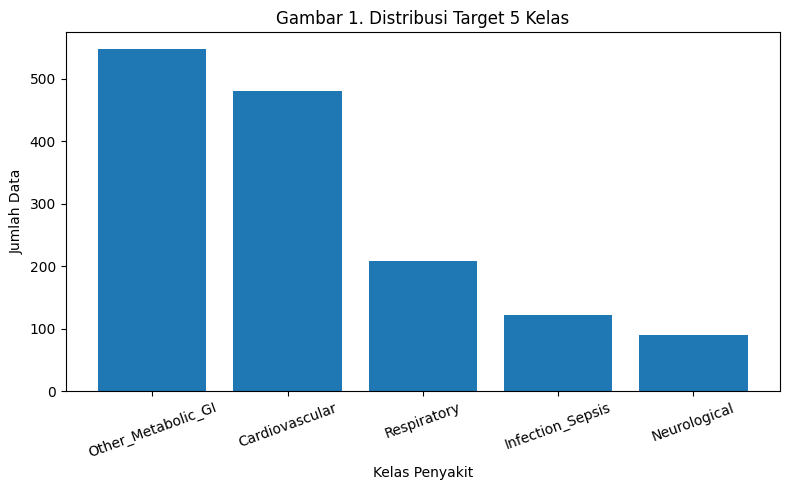

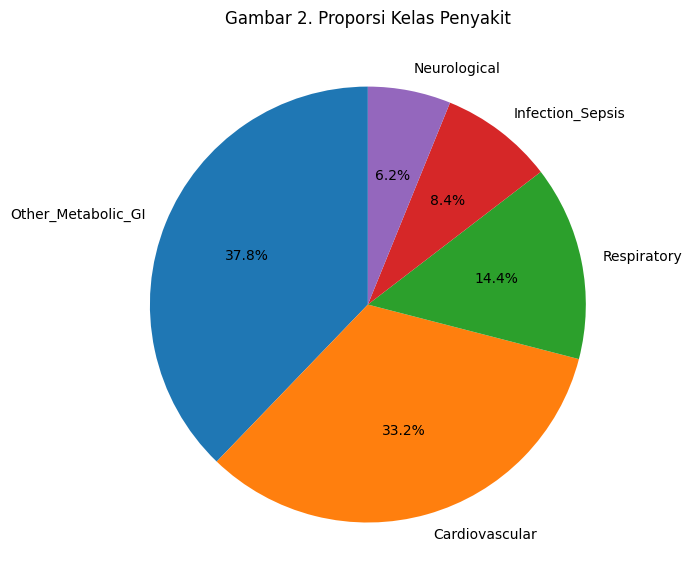

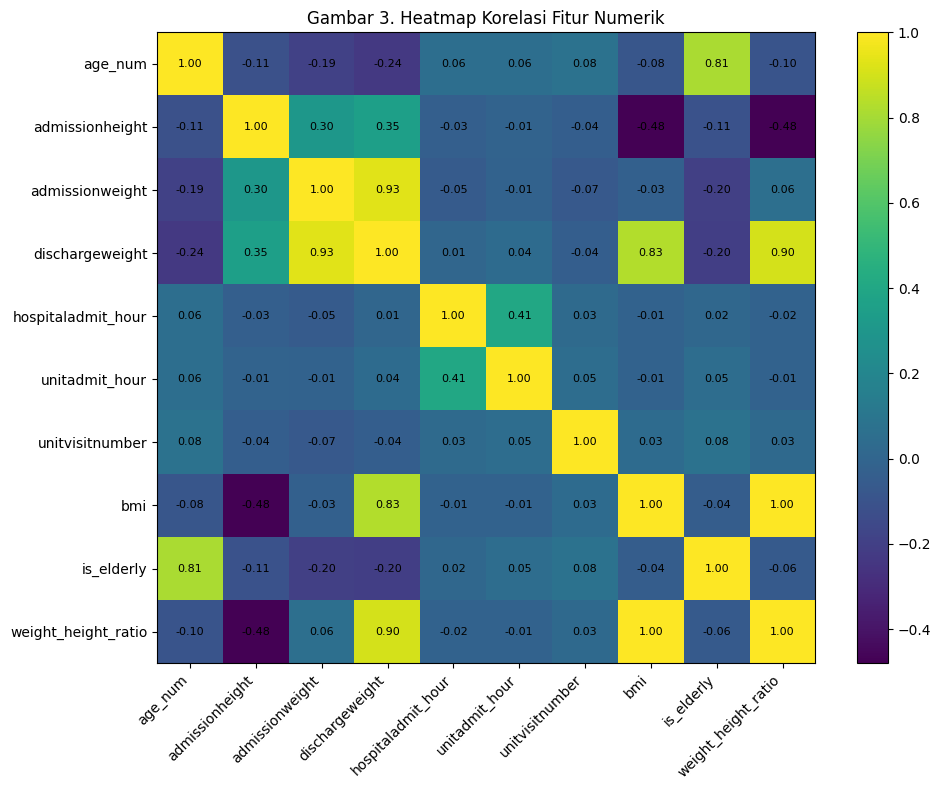

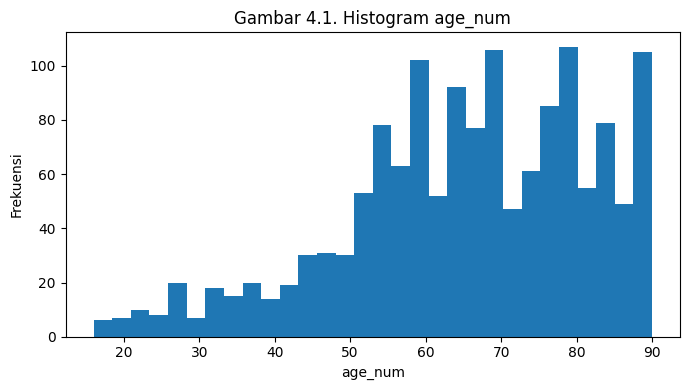

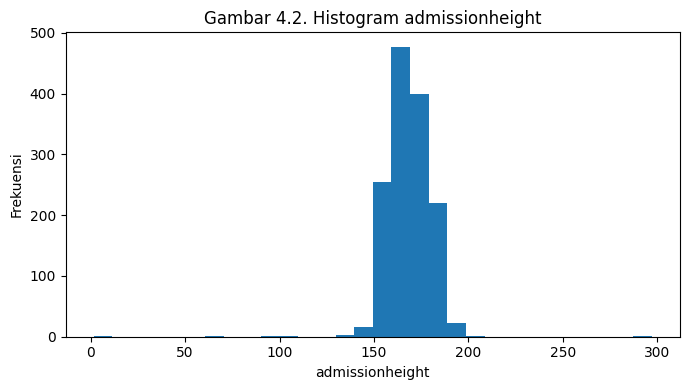

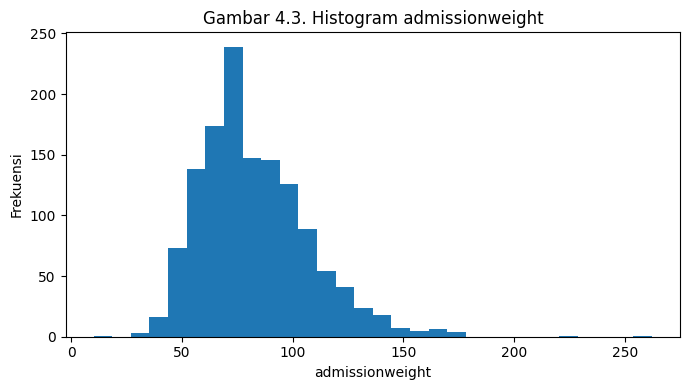

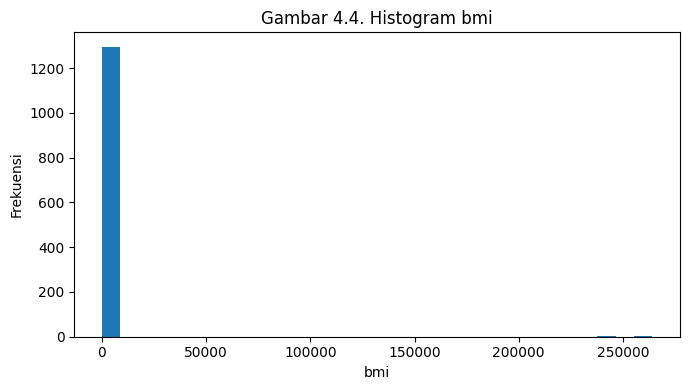

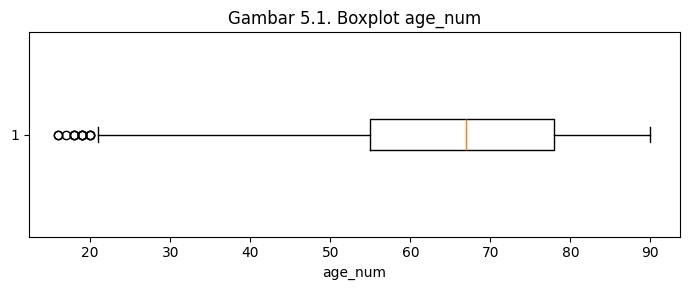

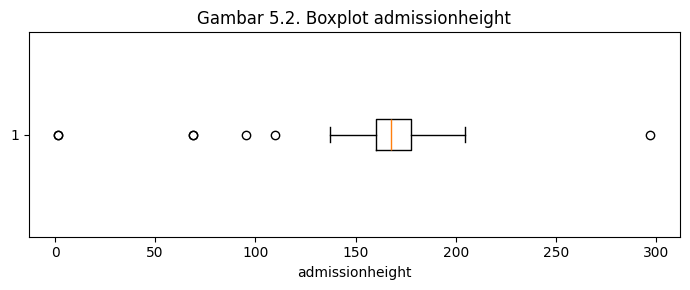

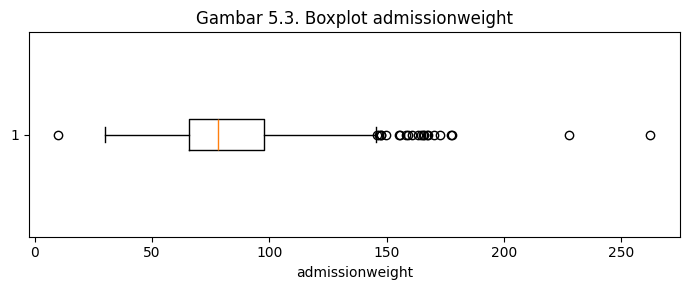

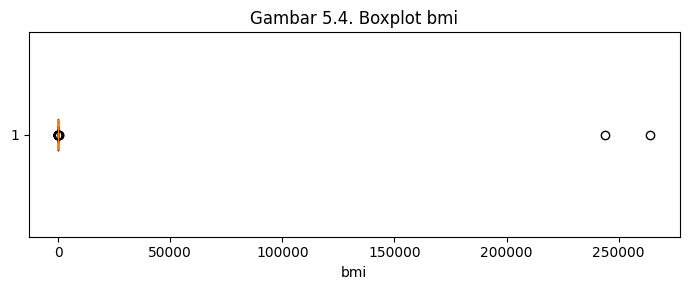

Gambar 6 tidak ditampilkan karena final_df belum tersedia.


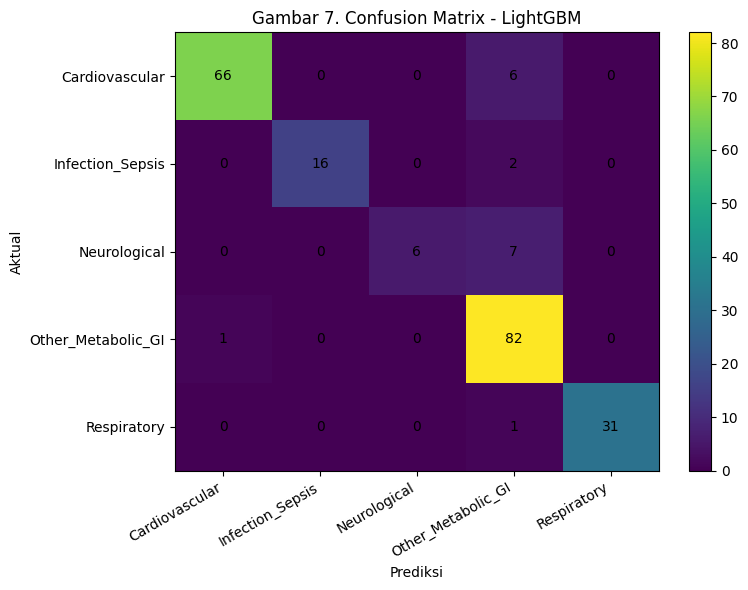

Top 20 Feature Importance:


,feature,importance
42,SVD_Component_42,683
43,SVD_Component_43,608
91,SVD_Component_91,574
29,SVD_Component_29,561
34,SVD_Component_34,555
61,SVD_Component_61,545
49,SVD_Component_49,544
25,SVD_Component_25,532
50,SVD_Component_50,465
45,SVD_Component_45,441


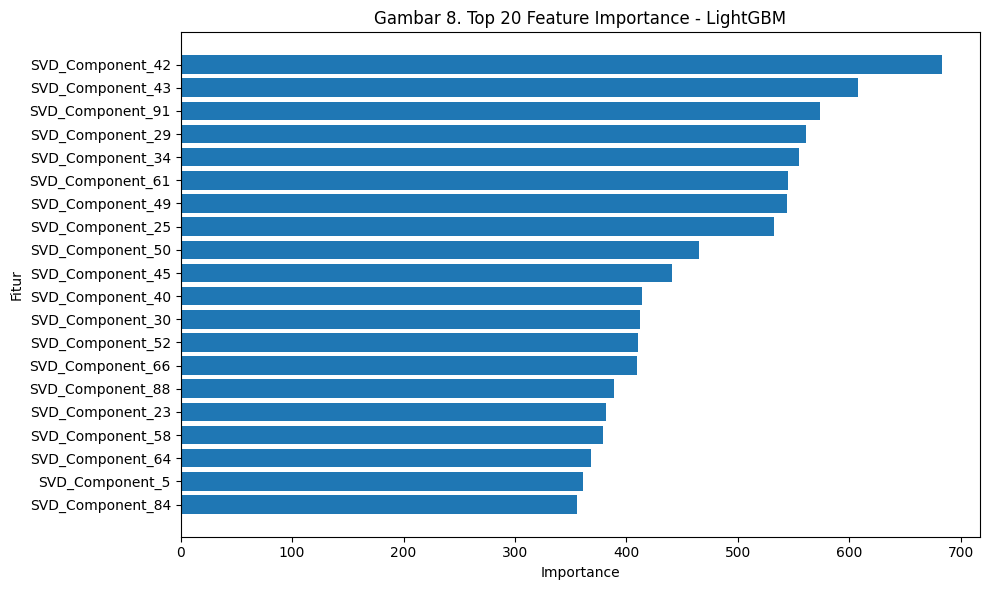

In [21]:
# ============================================================
# CELL VISUALISASI LENGKAP
# Menampilkan seluruh visualisasi penting untuk tugas
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# ============================================================
# PERSIAPAN DATA
# ============================================================

# Pastikan y_pred_final ada
try:
    y_pred_final
except NameError:
    y_pred_final = final_model.predict(X_test)

# Target counts
target_counts = data_model["target_5class"].value_counts()

# Fitur numerik yang ingin divisualisasikan
numeric_cols = [
    col for col in [
        "age_num",
        "admissionheight",
        "admissionweight",
        "dischargeweight",
        "hospitaladmit_hour",
        "unitadmit_hour",
        "unitvisitnumber",
        "bmi",
        "is_elderly",
        "weight_height_ratio"
    ]
    if col in data_model.columns
]

# ============================================================
# GAMBAR 1: DISTRIBUSI TARGET 5 KELAS
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(target_counts.index, target_counts.values)
plt.title("Gambar 1. Distribusi Target 5 Kelas")
plt.xlabel("Kelas Penyakit")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ============================================================
# GAMBAR 2: PIE CHART PROPORSI KELAS
# ============================================================

plt.figure(figsize=(7, 7))
plt.pie(
    target_counts.values,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Gambar 2. Proporsi Kelas Penyakit")
plt.tight_layout()
plt.show()

# ============================================================
# GAMBAR 3: HEATMAP KORELASI FITUR NUMERIK
# ============================================================

if len(numeric_cols) > 1:
    corr_matrix = data_model[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_matrix, aspect="auto")

    ax.set_xticks(np.arange(len(numeric_cols)))
    ax.set_yticks(np.arange(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
    ax.set_yticklabels(numeric_cols)

    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.colorbar(im)
    plt.title("Gambar 3. Heatmap Korelasi Fitur Numerik")
    plt.tight_layout()
    plt.show()
else:
    print("Gambar 3 tidak dapat ditampilkan karena fitur numerik terlalu sedikit.")

# ============================================================
# GAMBAR 4: HISTOGRAM FITUR NUMERIK
# ============================================================

hist_features = [col for col in ["age_num", "admissionheight", "admissionweight", "bmi"] if col in data_model.columns]

for idx, col in enumerate(hist_features, start=1):
    plt.figure(figsize=(7, 4))
    plt.hist(data_model[col].dropna(), bins=30)
    plt.title(f"Gambar 4.{idx}. Histogram {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()

# ============================================================
# GAMBAR 5: BOXPLOT FITUR NUMERIK
# ============================================================

for idx, col in enumerate(hist_features, start=1):
    plt.figure(figsize=(7, 3))
    plt.boxplot(data_model[col].dropna(), vert=False)
    plt.title(f"Gambar 5.{idx}. Boxplot {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# ============================================================
# GAMBAR 6: PERBANDINGAN AKURASI MODEL
# ============================================================

if "final_df" in globals():
    plot_df = final_df.copy()

    if "source" in plot_df.columns:
        labels = plot_df["model_name"] + " (" + plot_df["source"] + ")"
    else:
        labels = plot_df["model_name"]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, plot_df["accuracy"])
    plt.title("Gambar 6. Perbandingan Akurasi Model")
    plt.xlabel("Model")
    plt.ylabel("Akurasi")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Gambar 6 tidak ditampilkan karena final_df belum tersedia.")

# ============================================================
# GAMBAR 7: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, aspect="auto")

ax.set_xticks(np.arange(len(label_encoder.classes_)))
ax.set_yticks(np.arange(len(label_encoder.classes_)))
ax.set_xticklabels(label_encoder.classes_, rotation=30, ha="right")
ax.set_yticklabels(label_encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar(im)
plt.title(f"Gambar 7. Confusion Matrix - {final_model_name}")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

# ============================================================
# GAMBAR 8: FEATURE IMPORTANCE
# ============================================================

try:
    model_step = final_model.named_steps["model"]

    if hasattr(model_step, "feature_importances_"):
        importances = model_step.feature_importances_
        preprocessor_step = final_model.named_steps["preprocessor"]

        try:
            feature_names = preprocessor_step.get_feature_names_out()
        except:
            feature_names = [f"feature_{i}" for i in range(len(importances))]

        # Jika ada SVD, nama fitur diganti jadi komponen
        if "svd" in final_model.named_steps:
            feature_names = [f"SVD_Component_{i}" for i in range(len(importances))]

        fi_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values(by="importance", ascending=False).head(20)

        print("Top 20 Feature Importance:")
        display(fi_df)

        plt.figure(figsize=(10, 6))
        plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
        plt.title(f"Gambar 8. Top 20 Feature Importance - {final_model_name}")
        plt.xlabel("Importance")
        plt.ylabel("Fitur")
        plt.tight_layout()
        plt.show()

    else:
        print("Gambar 8 tidak dapat ditampilkan karena model final tidak memiliki feature_importances_.")
except Exception as e:
    print("Gambar 8 gagal ditampilkan:", e)

Bagian 9: Inference (Cell 19–20)

Tahap ini digunakan untuk melakukan prediksi terhadap data baru secara manual. Model yang telah dilatih digunakan untuk menguji apakah sistem dapat digunakan dalam kondisi nyata dengan input baru.

In [22]:
# ============================================================
# CELL 19: FUNGSI INFERENCE 1 DATA
# ============================================================

def prepare_single_input(
    gender,
    age,
    ethnicity,
    apacheadmissiondx,
    admissionheight,
    admissionweight,
    hospitaladmittime24,
    hospitaladmitsource,
    unittype,
    unitadmittime24,
    unitadmitsource,
    unitvisitnumber,
    unitstaytype,
    dischargeweight=None
):
    row = pd.DataFrame([{
        "gender": gender,
        "age": age,
        "ethnicity": ethnicity,
        "apacheadmissiondx": apacheadmissiondx,
        "admissionheight": admissionheight,
        "admissionweight": admissionweight,
        "hospitaladmittime24": hospitaladmittime24,
        "hospitaladmitsource": hospitaladmitsource,
        "unittype": unittype,
        "unitadmittime24": unitadmittime24,
        "unitadmitsource": unitadmitsource,
        "unitvisitnumber": unitvisitnumber,
        "unitstaytype": unitstaytype,
        "dischargeweight": dischargeweight
    }])

    # Feature engineering harus sama persis seperti training
    row["age_num"] = row["age"].apply(clean_age)
    row["hospitaladmit_hour"] = row["hospitaladmittime24"].apply(extract_hour)
    row["unitadmit_hour"] = row["unitadmittime24"].apply(extract_hour)
    row["apacheadmissiondx_clean"] = row["apacheadmissiondx"].apply(clean_text)

    row["height_m"] = row["admissionheight"] / 100
    row["bmi"] = row["admissionweight"] / (row["height_m"] ** 2)

    row["age_group"] = pd.cut(
        row["age_num"],
        bins=[0, 18, 35, 50, 65, 80, 120],
        labels=["0-18", "19-35", "36-50", "51-65", "66-80", "80+"],
        include_lowest=True
    )

    row["is_elderly"] = (row["age_num"] >= 65).astype(int)
    row["weight_height_ratio"] = row["admissionweight"] / row["admissionheight"]

    row["bmi_category"] = pd.cut(
        row["bmi"],
        bins=[0, 18.5, 25, 30, 100],
        labels=["underweight", "normal", "overweight", "obese"],
        include_lowest=True
    )

    row = row.drop(columns=["height_m"], errors="ignore")

    if baseline_mode == "strict":
        row_final = row[strict_features]
    else:
        row_final = row[score_features]

    pred_encoded = final_model.predict(row_final)
    pred_label = label_encoder.inverse_transform(pred_encoded)[0]

    return pred_label

In [23]:
# ============================================================
# CELL 20: UJI INFERENCE MANUAL
# ============================================================

hasil_prediksi = prepare_single_input(
    gender="Female",
    age="67",
    ethnicity="Caucasian",
    apacheadmissiondx="Sepsis, pulmonary",
    admissionheight=160,
    admissionweight=62,
    hospitaladmittime24="13:00:00",
    hospitaladmitsource="Emergency Department",
    unittype="Med-Surg ICU",
    unitadmittime24="14:00:00",
    unitadmitsource="Emergency Department",
    unitvisitnumber=1,
    unitstaytype="admit",
    dischargeweight=60
)

print("Hasil prediksi kelas penyakit:", hasil_prediksi)

Hasil prediksi kelas penyakit: Respiratory


In [24]:
# ============================================================
# CELL 20A: MENYIAPKAN OPSI DROPDOWN DARI DATASET
# ============================================================

gender_options = sorted(data_model["gender"].dropna().astype(str).unique().tolist())
ethnicity_options = sorted(data_model["ethnicity"].dropna().astype(str).unique().tolist())
hospital_source_options = sorted(data_model["hospitaladmitsource"].dropna().astype(str).unique().tolist())
unit_type_options = sorted(data_model["unittype"].dropna().astype(str).unique().tolist())
unit_source_options = sorted(data_model["unitadmitsource"].dropna().astype(str).unique().tolist())
unit_stay_type_options = sorted(data_model["unitstaytype"].dropna().astype(str).unique().tolist())
diagnosis_options = sorted(data_model["apacheadmissiondx_clean"].dropna().astype(str).unique().tolist())

print("Gender options:", gender_options[:10])
print("Ethnicity options:", ethnicity_options[:10])
print("Hospital source options:", hospital_source_options[:10])
print("Unit type options:", unit_type_options[:10])
print("Unit source options:", unit_source_options[:10])
print("Unit stay type options:", unit_stay_type_options[:10])
print("Total diagnosis options:", len(diagnosis_options))

Gender options: ['Female', 'Male', 'Unknown']
Ethnicity options: ['African American', 'Asian', 'Caucasian', 'Hispanic', 'Native American', 'Other/Unknown']
Hospital source options: ['Direct Admit', 'Emergency Department', 'Floor', 'ICU to SDU', 'Operating Room', 'Other Hospital', 'Other ICU', 'Recovery Room', 'Step-Down Unit (SDU)']
Unit type options: ['CCU-CTICU', 'CSICU', 'CTICU', 'Cardiac ICU', 'MICU', 'Med-Surg ICU', 'Neuro ICU', 'SICU']
Unit source options: ['Direct Admit', 'Emergency Department', 'Floor', 'ICU', 'ICU to SDU', 'Operating Room', 'Other Hospital', 'Other ICU', 'Recovery Room', 'Step-Down Unit (SDU)']
Unit stay type options: ['admit', 'readmit', 'stepdown/other', 'transfer']
Total diagnosis options: 198


Bagian 10: Deployment (Cell 21)

Pada bagian akhir dibuat aplikasi sederhana menggunakan Gradio untuk menampilkan model dalam bentuk web interface. Dengan ini, pengguna dapat melakukan prediksi secara langsung tanpa perlu menjalankan kode secara manual.

In [25]:
pip install --upgrade gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.14.0
    Uninstalling gradio_client-1.14.0:
      Successfully uninstalled gradio_client-1.14.0
  Attempting uninstall: gradio
    Found existing installation: gradio 5.50.0
    Uninstalling gradio-5.50.0:
      Successfully uninstalled gradio-5.50.0


In [26]:
# ============================================================
# CELL 21: WEB DEPLOYMENT DENGAN GRADIO
# VERSI INPUT LEBIH RAPI (BANYAK DROPDOWN)
# ============================================================

import gradio as gr

def predict_gradio(
    jenis_kelamin,
    usia,
    etnis,
    diagnosis_masuk,
    tinggi_badan,
    berat_badan_masuk,
    jam_masuk_rumah_sakit,
    sumber_masuk_rumah_sakit,
    tipe_unit,
    jam_masuk_unit,
    sumber_masuk_unit,
    nomor_kunjungan_unit,
    tipe_rawat_unit,
    berat_badan_keluar
):
    hasil = prepare_single_input(
        gender=jenis_kelamin,
        age=usia,
        ethnicity=etnis,
        apacheadmissiondx=diagnosis_masuk,
        admissionheight=float(tinggi_badan),
        admissionweight=float(berat_badan_masuk),
        hospitaladmittime24=jam_masuk_rumah_sakit,
        hospitaladmitsource=sumber_masuk_rumah_sakit,
        unittype=tipe_unit,
        unitadmittime24=jam_masuk_unit,
        unitadmitsource=sumber_masuk_unit,
        unitvisitnumber=int(nomor_kunjungan_unit),
        unitstaytype=tipe_rawat_unit,
        dischargeweight=float(berat_badan_keluar) if berat_badan_keluar not in ["", None] else None
    )
    return hasil

demo = gr.Interface(
    fn=predict_gradio,
    inputs=[
        gr.Dropdown(
            choices=gender_options,
            label="Jenis Kelamin",
            value=gender_options[0] if len(gender_options) > 0 else None
        ),
        gr.Textbox(label="Usia", value="67"),
        gr.Dropdown(
            choices=ethnicity_options,
            label="Etnis",
            value=ethnicity_options[0] if len(ethnicity_options) > 0 else None
        ),
        gr.Dropdown(
            choices=diagnosis_options,
            label="Diagnosis Saat Masuk",
            value=diagnosis_options[0] if len(diagnosis_options) > 0 else None
        ),
        gr.Number(label="Tinggi Badan (cm)", value=160),
        gr.Number(label="Berat Badan Saat Masuk (kg)", value=62),
        gr.Textbox(label="Jam Masuk Rumah Sakit (HH:MM:SS)", value="13:00:00"),
        gr.Dropdown(
            choices=hospital_source_options,
            label="Sumber Masuk Rumah Sakit",
            value=hospital_source_options[0] if len(hospital_source_options) > 0 else None
        ),
        gr.Dropdown(
            choices=unit_type_options,
            label="Tipe Unit",
            value=unit_type_options[0] if len(unit_type_options) > 0 else None
        ),
        gr.Textbox(label="Jam Masuk Unit (HH:MM:SS)", value="14:00:00"),
        gr.Dropdown(
            choices=unit_source_options,
            label="Sumber Masuk Unit",
            value=unit_source_options[0] if len(unit_source_options) > 0 else None
        ),
        gr.Number(label="Nomor Kunjungan Unit", value=1),
        gr.Dropdown(
            choices=unit_stay_type_options,
            label="Tipe Rawat Unit",
            value=unit_stay_type_options[0] if len(unit_stay_type_options) > 0 else None
        ),
        gr.Number(label="Berat Badan Saat Keluar (kg)", value=60)
    ],
    outputs=gr.Textbox(label="Hasil Prediksi Kelas Penyakit"),
    title="Klasifikasi Multi Penyakit (5 Kelas) - EHR",
    description="Aplikasi prediksi kelas penyakit pasien berdasarkan data Electronic Health Record."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://86be44c242bf03336f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
